Main - Ciencia de Dados

Anos disponíveis para análise: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Dados de 2015 carregados: 122161 registros
Dados de 2016 carregados: 96363 registros
Dados de 2017 carregados: 89567 registros
Dados de 2018 carregados: 69333 registros
Dados de 2019 carregados: 67558 registros
Dados de 2020 carregados: 63585 registros
Dados de 2021 carregados: 64567 registros
Dados de 2022 carregados: 64606 registros
Dados de 2023 carregados: 67766 registros
Dados de 2024 carregados: 73156 registros

Dataset combinado: (778662, 31)
EVOLUÇÃO TEMPORAL DE ACIDENTES


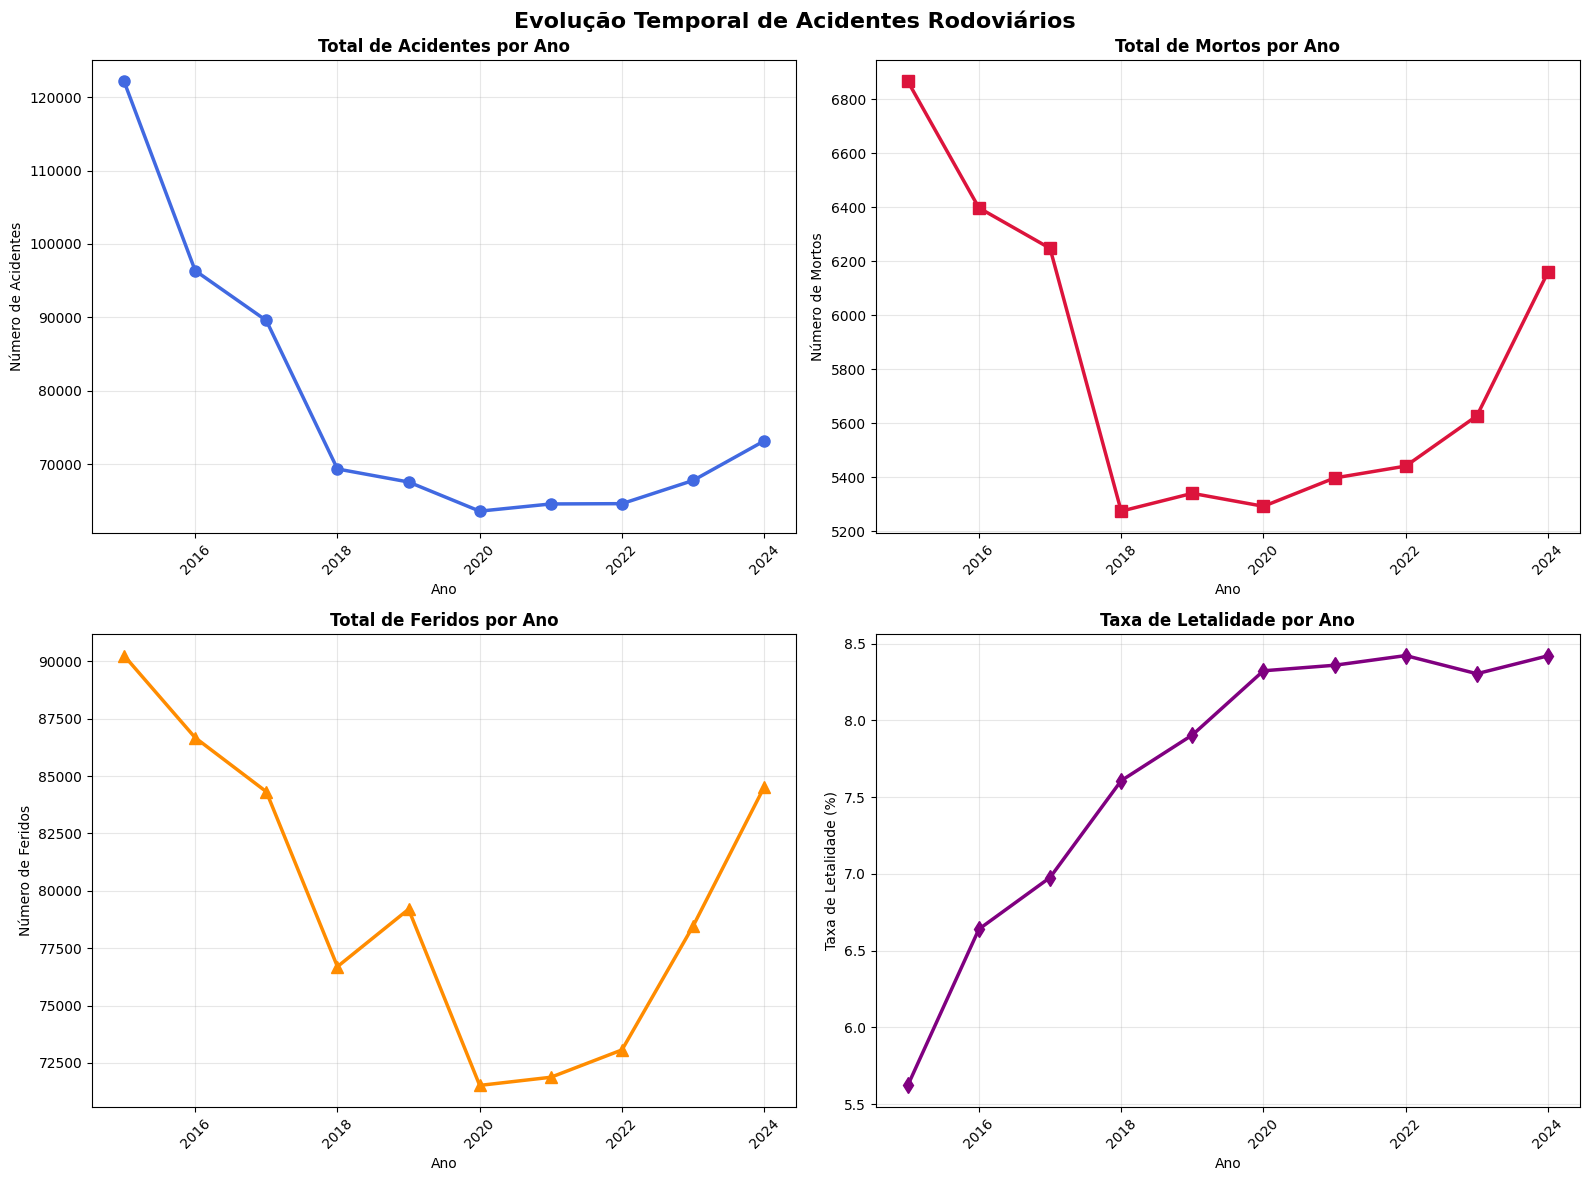


COMPARAÇÃO DE MÉDIAS MENSAIS ENTRE ANOS


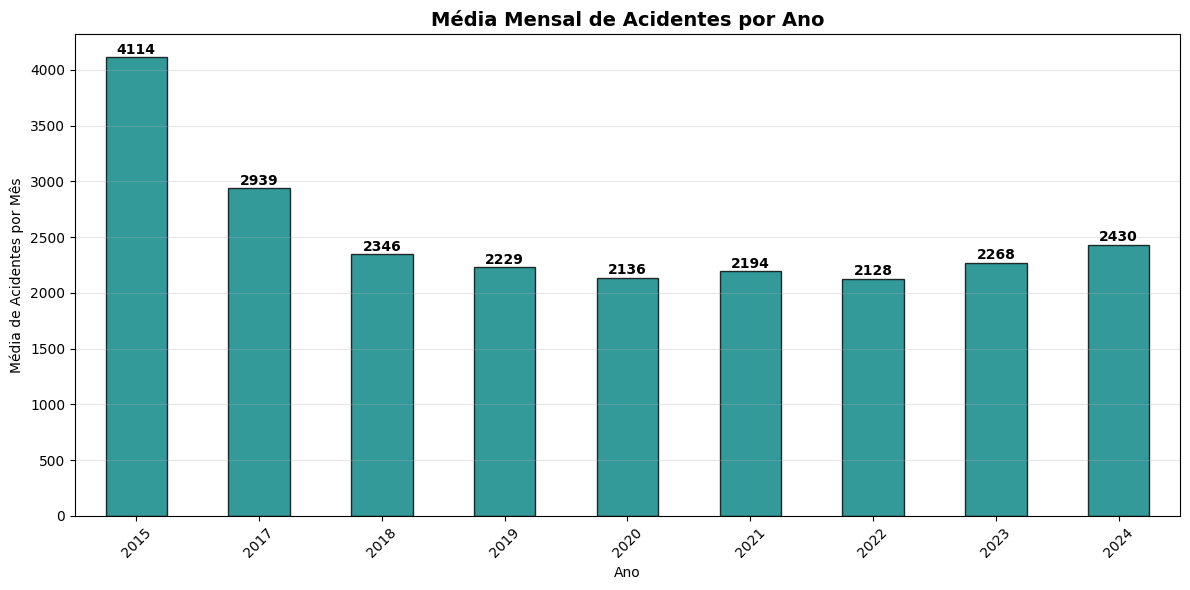


SAZONALIDADE - COMPARAÇÃO MENSAL ENTRE ANOS


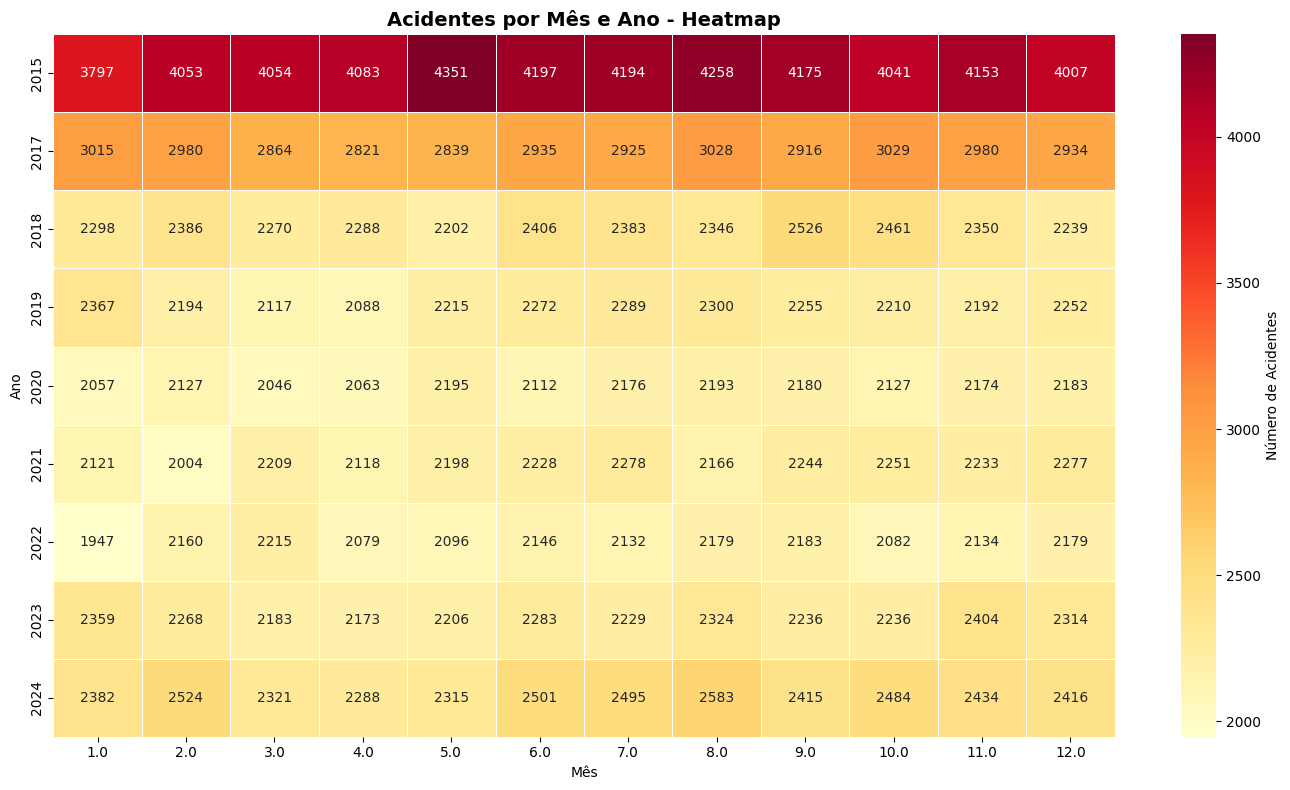


EVOLUÇÃO DAS PRINCIPAIS CAUSAS DE ACIDENTES


<Figure size 1400x800 with 0 Axes>

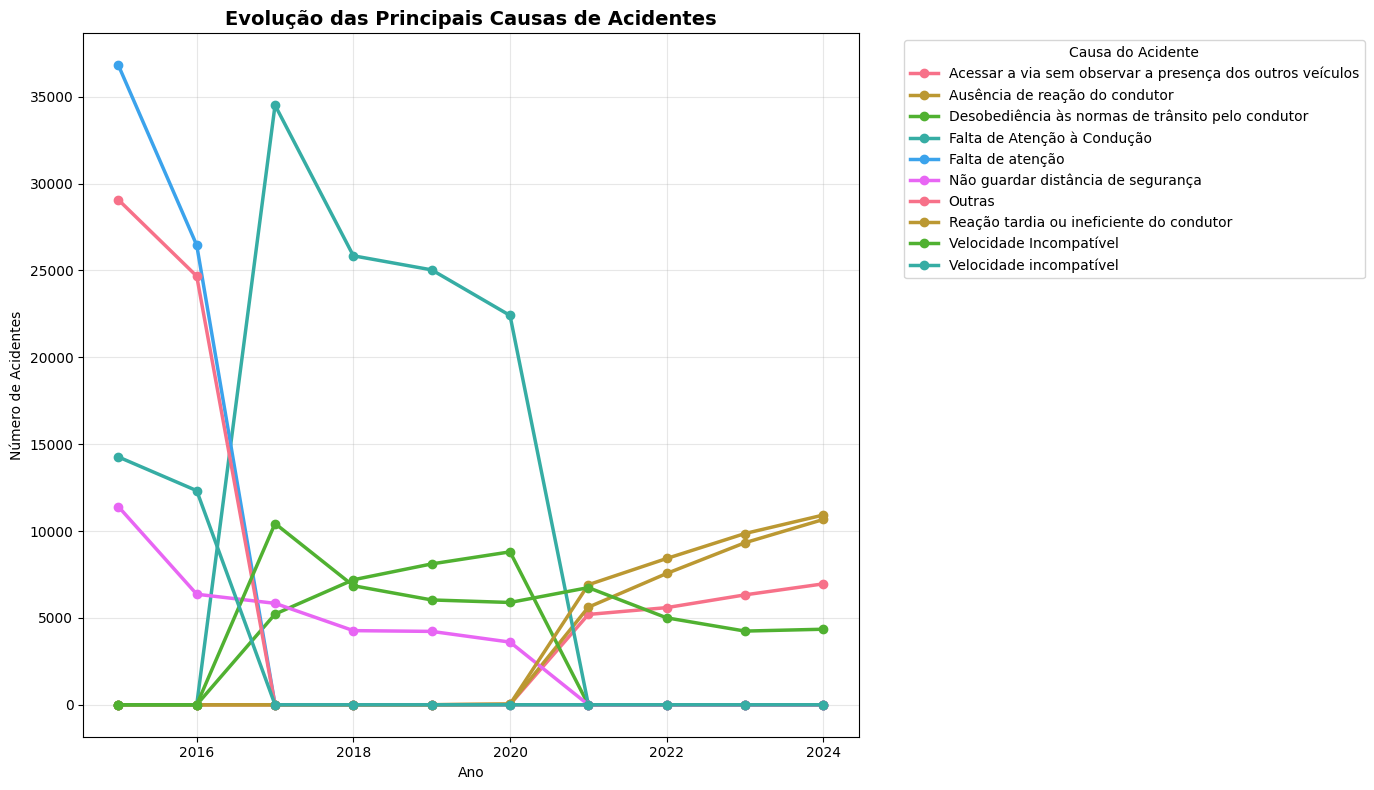


COMPARAÇÃO ENTRE ESTADOS AO LONGO DOS ANOS


<Figure size 1400x800 with 0 Axes>

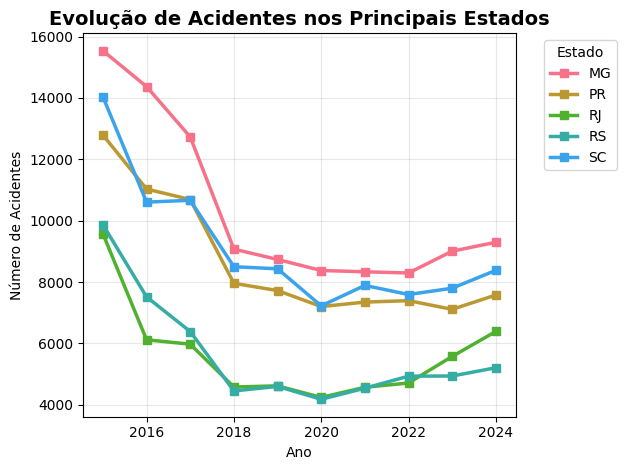


TAXA DE LETALIDADE POR ANO E ESTADO


<Figure size 1400x800 with 0 Axes>

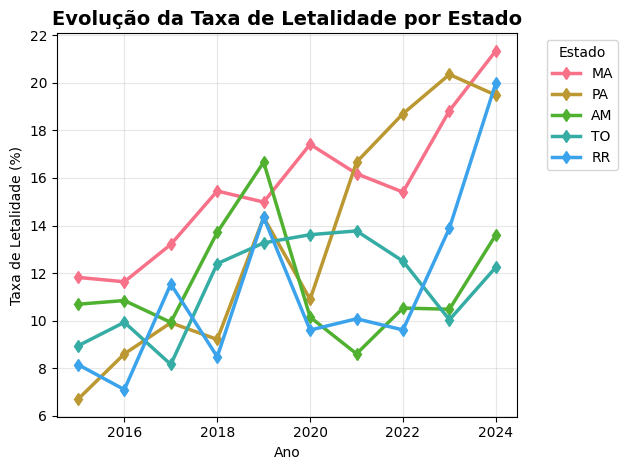


COMPARAÇÃO DE TIPOS DE ACIDENTES AO LONGO DOS ANOS


<Figure size 1400x800 with 0 Axes>

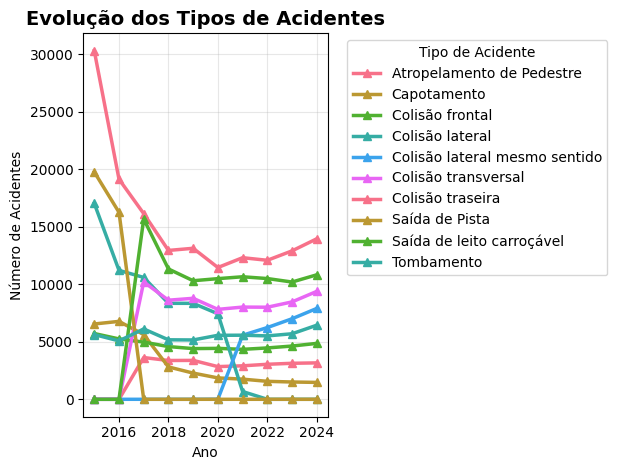


ANÁLISE DE TENDÊNCIAS


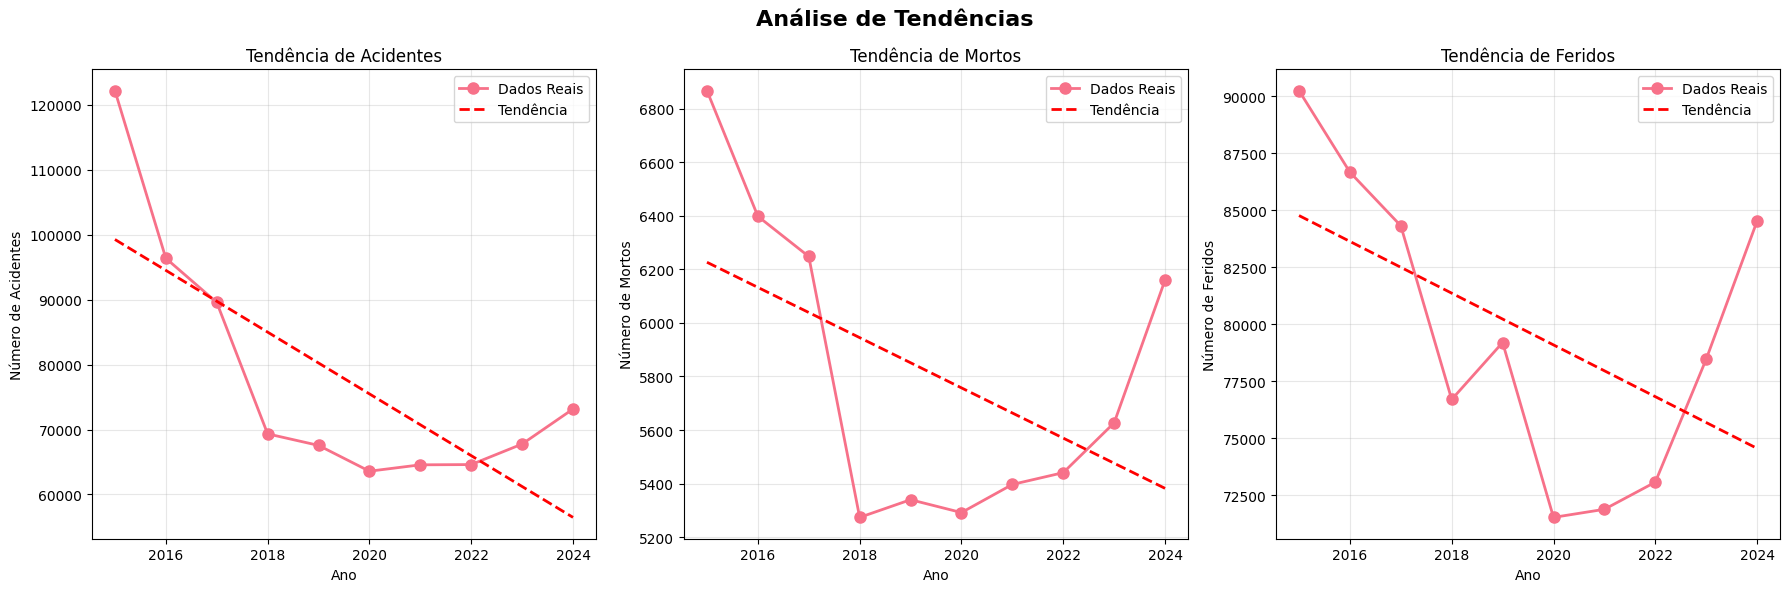


Variação Percentual no Período:
Acidentes: -40.12%
Mortos: -10.30%
Feridos: -6.34%

COMPARAÇÃO DE INDICADORES POR ANO


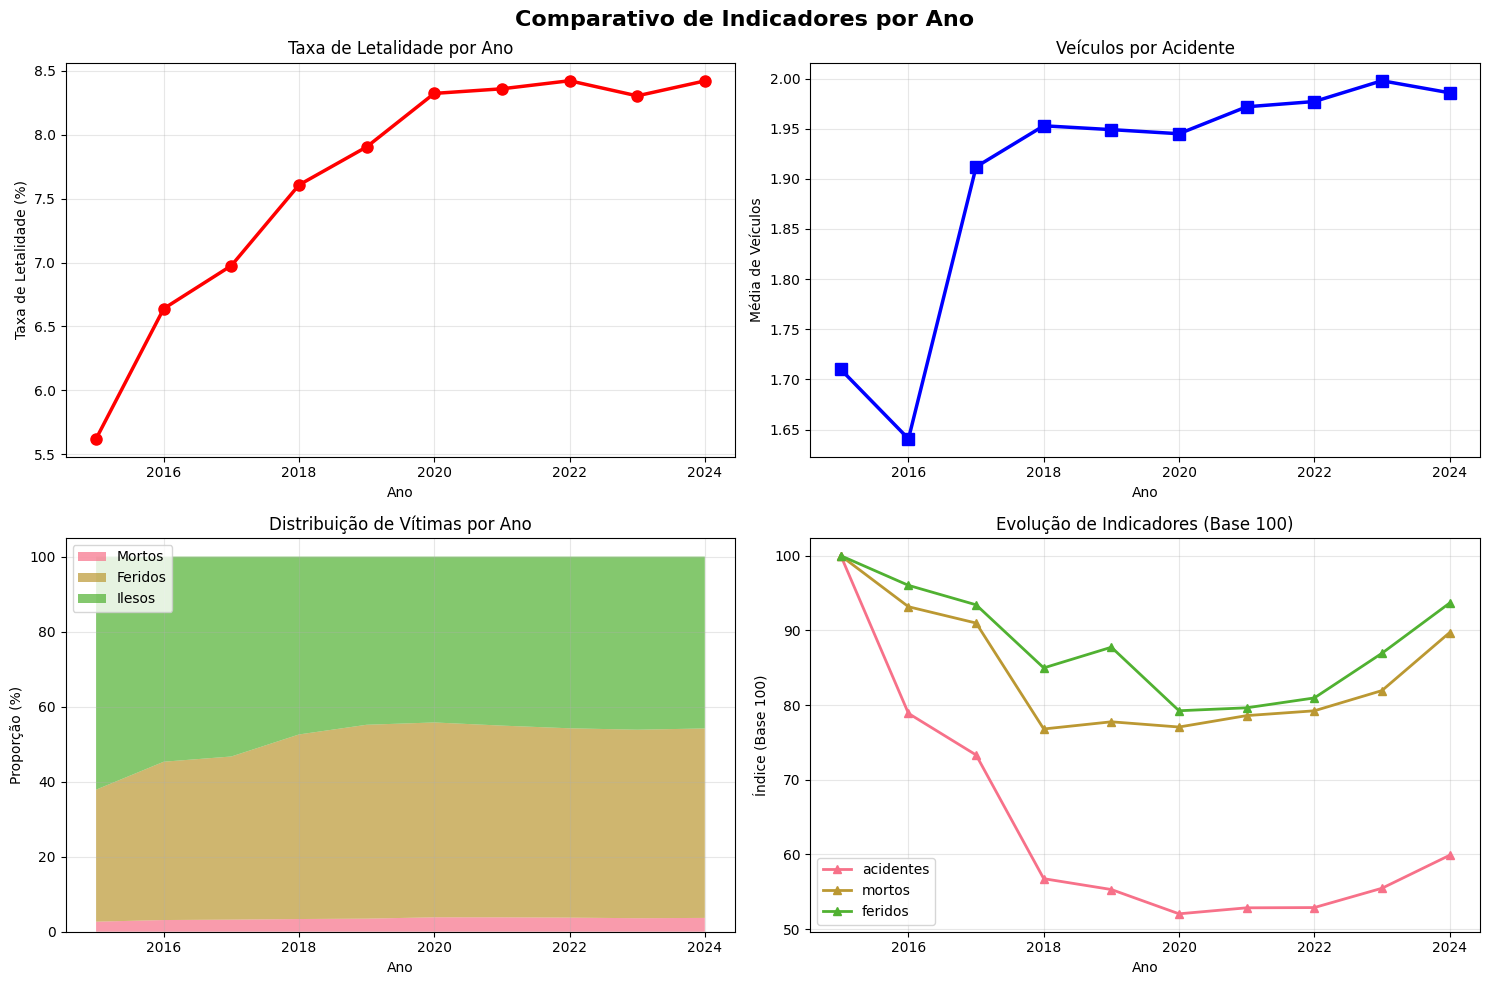


ANÁLISE TEMPORAL CONCLUÍDA!
Foram analisados dados de 10 anos: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Período coberto: 2015 a 2024
Total de registros: 778,662
Total de acidentes: 778,657
Total de mortos: 58,044
Total de feridos: 796,577


In [ ]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# Configuração do estilo
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Lista de arquivos disponíveis
anos_disponiveis = []
for ano in range(2015, 2025):
    if glob.glob(f'datatran{ano}.csv'):
        anos_disponiveis.append(ano)

print(f"Anos disponíveis para análise: {anos_disponiveis}")

# Carregar dados de todos os anos disponíveis
dfs = []
for ano in anos_disponiveis:
    try:
        df_ano = pd.read_csv(f'datatran{ano}.csv', sep=';', encoding='latin-1', low_memory=False)
        df_ano['ano'] = ano  # Adicionar coluna de ano
        dfs.append(df_ano)
        print(f"Dados de {ano} carregados: {len(df_ano)} registros")
    except Exception as e:
        print(f"Erro ao carregar {ano}: {e}")

# Combinar todos os dados em um único DataFrame
df = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df.shape}")

# Pré-processamento dos dados

# Pré-processamento dos dados
df['data_inversa'] = pd.to_datetime(
    df['data_inversa'], 
    errors='coerce',
    dayfirst=True,
    infer_datetime_format=True
)

df['mes'] = df['data_inversa'].dt.month
df['dia_semana_num'] = df['data_inversa'].dt.dayofweek


df['hora'] = pd.to_datetime(df['horario'], errors='coerce').dt.hour
df['severidade'] = df['mortos'].apply(lambda x: 'Fatal' if x > 0 else 'Não Fatal')

# 1. EVOLUÇÃO TEMPORAL DE ACIDENTES
print("="*60)
print("EVOLUÇÃO TEMPORAL DE ACIDENTES")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evolução Temporal de Acidentes Rodoviários', fontsize=16, fontweight='bold')

# Acidentes por ano
acidentes_por_ano = df.groupby('ano').size()
axes[0,0].plot(acidentes_por_ano.index, acidentes_por_ano.values, 
               marker='o', linewidth=2.5, markersize=8, color='royalblue')
axes[0,0].set_title('Total de Acidentes por Ano', fontweight='bold')
axes[0,0].set_xlabel('Ano')
axes[0,0].set_ylabel('Número de Acidentes')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Mortos por ano
mortos_por_ano = df.groupby('ano')['mortos'].sum()
axes[0,1].plot(mortos_por_ano.index, mortos_por_ano.values, 
               marker='s', linewidth=2.5, markersize=8, color='crimson')
axes[0,1].set_title('Total de Mortos por Ano', fontweight='bold')
axes[0,1].set_xlabel('Ano')
axes[0,1].set_ylabel('Número de Mortos')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# Feridos por ano
feridos_por_ano = df.groupby('ano')['feridos'].sum()
axes[1,0].plot(feridos_por_ano.index, feridos_por_ano.values, 
               marker='^', linewidth=2.5, markersize=8, color='darkorange')
axes[1,0].set_title('Total de Feridos por Ano', fontweight='bold')
axes[1,0].set_xlabel('Ano')
axes[1,0].set_ylabel('Número de Feridos')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].tick_params(axis='x', rotation=45)

# Taxa de letalidade por ano
letalidade_por_ano = (mortos_por_ano / acidentes_por_ano * 100)
axes[1,1].plot(letalidade_por_ano.index, letalidade_por_ano.values, 
               marker='d', linewidth=2.5, markersize=8, color='purple')
axes[1,1].set_title('Taxa de Letalidade por Ano', fontweight='bold')
axes[1,1].set_xlabel('Ano')
axes[1,1].set_ylabel('Taxa de Letalidade (%)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. COMPARAÇÃO DE MÉDIAS MENSAIS ENTRE ANOS
print("\n" + "="*60)
print("COMPARAÇÃO DE MÉDIAS MENSAIS ENTRE ANOS")
print("="*60)

# Calcular médias mensais para cada ano
media_mensal_por_ano = df.groupby(['ano', 'mes']).size().groupby('ano').mean()

plt.figure(figsize=(12, 6))
media_mensal_por_ano.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)
plt.title('Média Mensal de Acidentes por Ano', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Média de Acidentes por Mês')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(media_mensal_por_ano):
    plt.text(i, v + 5, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. SAZONALIDADE - COMPARAÇÃO MENSAL ENTRE ANOS
print("\n" + "="*60)
print("SAZONALIDADE - COMPARAÇÃO MENSAL ENTRE ANOS")
print("="*60)

# Preparar dados para heatmap de sazonalidade
acidentes_mensais = df.groupby(['ano', 'mes']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(acidentes_mensais, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Número de Acidentes'})
plt.title('Acidentes por Mês e Ano - Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.tight_layout()
plt.show()

# 4. EVOLUÇÃO DAS PRINCIPAIS CAUSAS DE ACIDENTES
print("\n" + "="*60)
print("EVOLUÇÃO DAS PRINCIPAIS CAUSAS DE ACIDENTES")
print("="*60)

# Identificar as 5 principais causas ao longo dos anos
top_causas = df['causa_acidente'].value_counts().head(10).index.tolist()

# Filtrar apenas as principais causas
df_top_causas = df[df['causa_acidente'].isin(top_causas)]

# Contar ocorrências por ano e causa
causas_por_ano = df_top_causas.groupby(['ano', 'causa_acidente']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
causas_por_ano.plot(kind='line', marker='o', linewidth=2.5, markersize=6, figsize=(14, 8))
plt.title('Evolução das Principais Causas de Acidentes', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.legend(title='Causa do Acidente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. COMPARAÇÃO ENTRE ESTADOS AO LONGO DOS ANOS
print("\n" + "="*60)
print("COMPARAÇÃO ENTRE ESTADOS AO LONGO DOS ANOS")
print("="*60)

# Top 5 estados com mais acidentes
top_estados = df['uf'].value_counts().head(5).index.tolist()
df_top_estados = df[df['uf'].isin(top_estados)]

# Acidentes por ano e estado
acidentes_estado_ano = df_top_estados.groupby(['ano', 'uf']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
acidentes_estado_ano.plot(kind='line', marker='s', linewidth=2.5, markersize=6)
plt.title('Evolução de Acidentes nos Principais Estados', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 5.999. TAXA DE LETALIDADE POR ANO E ESTADO

corr = df.corr(numeric_only=True)

# Cria o heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Heatmap de Correlação das Variáveis", fontsize=16)
plt.show()

# 6. TAXA DE LETALIDADE POR ANO E ESTADO
print("\n" + "="*60)
print("TAXA DE LETALIDADE POR ANO E ESTADO")
print("="*60)

# Calcular taxa de letalidade por ano e estado
letalidade_estado_ano = (df[df['mortos'] > 0].groupby(['ano', 'uf']).size() / 
                         df.groupby(['ano', 'uf']).size() * 100).unstack(fill_value=0)

# Selecionar apenas os estados com maior taxa média de letalidade
estados_mais_letalidade = letalidade_estado_ano.mean().nlargest(5).index
letalidade_estado_ano = letalidade_estado_ano[estados_mais_letalidade]

plt.figure(figsize=(14, 8))
letalidade_estado_ano.plot(kind='line', marker='d', linewidth=2.5, markersize=6)
plt.title('Evolução da Taxa de Letalidade por Estado', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Taxa de Letalidade (%)')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. COMPARAÇÃO DE TIPOS DE ACIDENTES AO LONGO DOS ANOS
print("\n" + "="*60)
print("COMPARAÇÃO DE TIPOS DE ACIDENTES AO LONGO DOS ANOS")
print("="*60)

# Top 5 tipos de acidentes
top_tipos = df['tipo_acidente'].value_counts().head(10).index.tolist()
df_top_tipos = df[df['tipo_acidente'].isin(top_tipos)]

# Contar por ano e tipo
tipos_por_ano = df_top_tipos.groupby(['ano', 'tipo_acidente']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
tipos_por_ano.plot(kind='line', marker='^', linewidth=2.5, markersize=6)
plt.title('Evolução dos Tipos de Acidentes', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.legend(title='Tipo de Acidente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. ANÁLISE DE TENDÊNCIAS
print("\n" + "="*60)
print("ANÁLISE DE TENDÊNCIAS")
print("="*60)

from sklearn.linear_model import LinearRegression

# Preparar dados para análise de tendência
tendencia_data = df.groupby('ano').agg({
    'id': 'count',
    'mortos': 'sum',
    'feridos': 'sum'
}).rename(columns={'id': 'acidentes'})

# Calcular tendências
anos = np.array(tendencia_data.index).reshape(-1, 1)
acidentes = tendencia_data['acidentes'].values
mortos = tendencia_data['mortos'].values
feridos = tendencia_data['feridos'].values

# Modelos de regressão linear
model_acidentes = LinearRegression().fit(anos, acidentes)
model_mortos = LinearRegression().fit(anos, mortos)
model_feridos = LinearRegression().fit(anos, feridos)

# Previsões
anos_range = np.array([min(anos), max(anos)]).reshape(-1, 1)
acidentes_trend = model_acidentes.predict(anos_range)
mortos_trend = model_mortos.predict(anos_range)
feridos_trend = model_feridos.predict(anos_range)

# Plotar tendências
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise de Tendências', fontsize=16, fontweight='bold')

# Tendência de acidentes
axes[0].plot(anos, acidentes, 'o-', label='Dados Reais', linewidth=2, markersize=8)
axes[0].plot(anos_range, acidentes_trend, 'r--', label='Tendência', linewidth=2)
axes[0].set_title('Tendência de Acidentes')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Número de Acidentes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tendência de mortos
axes[1].plot(anos, mortos, 'o-', label='Dados Reais', linewidth=2, markersize=8)
axes[1].plot(anos_range, mortos_trend, 'r--', label='Tendência', linewidth=2)
axes[1].set_title('Tendência de Mortos')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Número de Mortos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Tendência de feridos
axes[2].plot(anos, feridos, 'o-', label='Dados Reais', linewidth=2, markersize=8)
axes[2].plot(anos_range, feridos_trend, 'r--', label='Tendência', linewidth=2)
axes[2].set_title('Tendência de Feridos')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Número de Feridos')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular variações percentuais
def calcular_variacao(serie):
    if len(serie) > 1:
        return ((serie.iloc[-1] - serie.iloc[0]) / serie.iloc[0] * 100)
    return 0

variacao_acidentes = calcular_variacao(tendencia_data['acidentes'])
variacao_mortos = calcular_variacao(tendencia_data['mortos'])
variacao_feridos = calcular_variacao(tendencia_data['feridos'])

print(f"\nVariação Percentual no Período:")
print(f"Acidentes: {variacao_acidentes:+.2f}%")
print(f"Mortos: {variacao_mortos:+.2f}%")
print(f"Feridos: {variacao_feridos:+.2f}%")

# 9. COMPARAÇÃO DE INDICADORES POR ANO
print("\n" + "="*60)
print("COMPARAÇÃO DE INDICADORES POR ANO")
print("="*60)

# Calcular indicadores por ano
indicadores_ano = df.groupby('ano').agg({
    'id': 'count',
    'mortos': 'sum',
    'feridos': 'sum',
    'veiculos': 'sum',
    'ilesos': 'sum'
}).rename(columns={'id': 'acidentes'})

indicadores_ano['taxa_letalidade'] = indicadores_ano['mortos'] / indicadores_ano['acidentes'] * 100
indicadores_ano['veiculos_por_acidente'] = indicadores_ano['veiculos'] / indicadores_ano['acidentes']

# Plotar comparativo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparativo de Indicadores por Ano', fontsize=16, fontweight='bold')

# Taxa de letalidade
axes[0,0].plot(indicadores_ano.index, indicadores_ano['taxa_letalidade'], 
               marker='o', linewidth=2.5, markersize=8, color='red')
axes[0,0].set_title('Taxa de Letalidade por Ano')
axes[0,0].set_xlabel('Ano')
axes[0,0].set_ylabel('Taxa de Letalidade (%)')
axes[0,0].grid(True, alpha=0.3)

# Veículos por acidente
axes[0,1].plot(indicadores_ano.index, indicadores_ano['veiculos_por_acidente'], 
               marker='s', linewidth=2.5, markersize=8, color='blue')
axes[0,1].set_title('Veículos por Acidente')
axes[0,1].set_xlabel('Ano')
axes[0,1].set_ylabel('Média de Veículos')
axes[0,1].grid(True, alpha=0.3)

# Proporção de vítimas (stacked area)
proporcao_vitimas = indicadores_ano[['mortos', 'feridos', 'ilesos']].div(indicadores_ano[['mortos', 'feridos', 'ilesos']].sum(axis=1), axis=0) * 100
axes[1,0].stackplot(proporcao_vitimas.index, proporcao_vitimas.T, 
                    labels=['Mortos', 'Feridos', 'Ilesos'], alpha=0.7)
axes[1,0].set_title('Distribuição de Vítimas por Ano')
axes[1,0].set_xlabel('Ano')
axes[1,0].set_ylabel('Proporção (%)')
axes[1,0].legend(loc='upper left')
axes[1,0].grid(True, alpha=0.3)

# Comparativo de índices (normalizado)
indicadores_norm = indicadores_ano[['acidentes', 'mortos', 'feridos']]
indicadores_norm = indicadores_norm.div(indicadores_norm.iloc[0], axis=1) * 100

for col in indicadores_norm.columns:
    axes[1,1].plot(indicadores_norm.index, indicadores_norm[col], 
                   marker='^', linewidth=2, markersize=6, label=col)

axes[1,1].set_title('Evolução de Indicadores (Base 100)')
axes[1,1].set_xlabel('Ano')
axes[1,1].set_ylabel('Índice (Base 100)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANÁLISE TEMPORAL CONCLUÍDA!")
print("="*60)
print(f"Foram analisados dados de {len(anos_disponiveis)} anos: {anos_disponiveis}")
print(f"Período coberto: {min(anos_disponiveis)} a {max(anos_disponiveis)}")
print(f"Total de registros: {len(df):,}")
print(f"Total de acidentes: {df['id'].nunique():,}")
print(f"Total de mortos: {df['mortos'].sum():,}")
print(f"Total de feridos: {df['feridos'].sum():,}")